In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv


In [2]:
import torch
import torch.optim as optim
from scipy.stats import ttest_ind, norm, gaussian_kde
from statsmodels.stats.multitest import multipletests
from sklearn.model_selection import train_test_split
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             confusion_matrix, precision_recall_curve, auc)
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv")

print(f"Shape: {df.shape}")
print(df['Class'].value_counts())

Shape: (284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64


In [4]:
print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

Split Normal / Fraud

In [5]:
df_normal = df[df['Class'] == 0]
df_fraud   = df[df['Class'] == 1]

normal_train, normal_test = train_test_split(df_normal, test_size=0.2, random_state=42)

test_set = pd.concat([normal_test, df_fraud]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Training normal transactions : {len(normal_train)}")
print(f"Test normal transactions     : {len(normal_test)}")
print(f"Test fraud transactions      : {len(df_fraud)}")
print(f"Total test set               : {len(test_set)}")

Training normal transactions : 227452
Test normal transactions     : 56863
Test fraud transactions      : 492
Total test set               : 57355


Feature Selection

In [6]:
def select_features_fdr(normal_df, fraud_df, alpha=0.05):
    features = normal_df.drop(columns=['Class']).columns.tolist()
    p_values = []

    for f in features:
        _, p = ttest_ind(normal_df[f], fraud_df[f])
        p_values.append(p)

    p_values = np.array(p_values)
    reject, _, _, _ = multipletests(p_values, alpha=alpha, method='fdr_bh')

    selected = [f for f, r in zip(features, reject) if r]
    selected_p = p_values[reject]

    return selected, p_values, selected_p

In [7]:
selected_features, all_p_values, selected_p_values = select_features_fdr(
    normal_train, df_fraud
)

print(f"Selected {len(selected_features)} / {len(all_p_values)} features")
print(selected_features)

Selected 27 / 30 features
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V24', 'V26', 'V27', 'V28', 'Amount']


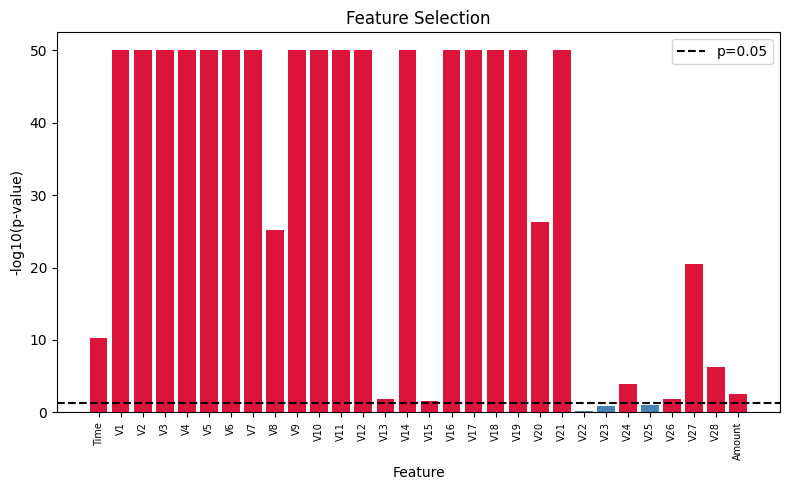

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

feature_names = normal_train.drop(columns=['Class']).columns.tolist()
log_p = -np.log10(all_p_values + 1e-300)
log_p_display = np.clip(log_p, 0, 50)
colors = ['crimson' if f in selected_features else 'steelblue' for f in feature_names]

ax.bar(range(len(log_p_display)), log_p_display, color=colors)
ax.axhline(-np.log10(0.05), color='black', linestyle='--', label='p=0.05')
ax.set_title('Feature Selection')
ax.set_xlabel('Feature')
ax.set_ylabel('-log10(p-value)')
ax.set_xticks(range(len(feature_names)))
ax.set_xticklabels(feature_names, rotation=90, fontsize=7)
ax.legend()
plt.tight_layout()
plt.savefig('plot2_feature_selection.pdf', bbox_inches='tight')
plt.show()

Fit Gaussian Per Feature

In [9]:
def fit_gaussian_pytorch(data_np, n_iter=100):
    data = torch.tensor(data_np, dtype=torch.float32)

    mu        = torch.tensor(float(data_np.mean()), requires_grad=True)
    log_sigma = torch.tensor(float(np.log(data_np.std() + 1e-6)), requires_grad=True)

    optimizer = optim.LBFGS([mu, log_sigma], max_iter=n_iter)

    def closure():
        optimizer.zero_grad()
        sigma = torch.exp(log_sigma)
        loss  = 0.5 * torch.mean(((data - mu) / sigma) ** 2) + log_sigma
        loss.backward()
        return loss

    optimizer.step(closure)

    return mu.item(), torch.exp(log_sigma).item()

In [10]:
fitted_params = {}

for f in selected_features:
    mu, sigma = fit_gaussian_pytorch(normal_train[f].values)
    fitted_params[f] = (mu, sigma)
    print(f"{f}: mu={mu:.4f}, sigma={sigma:.4f}")

Time: mu=94813.7188, sigma=47499.6406
V1: mu=0.0083, sigma=1.9328
V2: mu=-0.0051, sigma=1.6369
V3: mu=0.0110, sigma=1.4614
V4: mu=-0.0097, sigma=1.3994
V5: mu=0.0024, sigma=1.3434
V6: mu=0.0018, sigma=1.3219
V7: mu=0.0110, sigma=1.1625
V8: mu=-0.0013, sigma=1.1626
V9: mu=0.0023, sigma=1.0892
V10: mu=0.0106, sigma=1.0464
V11: mu=-0.0056, sigma=1.0032
V12: mu=0.0093, sigma=0.9478
V13: mu=0.0017, sigma=0.9962
V14: mu=0.0125, sigma=0.8972
V15: mu=-0.0000, sigma=0.9136
V16: mu=0.0083, sigma=0.8453
V17: mu=0.0119, sigma=0.7512
V18: mu=0.0037, sigma=0.8251
V19: mu=-0.0016, sigma=0.8122
V20: mu=-0.0006, sigma=0.7663
V21: mu=-0.0006, sigma=0.7179
V24: mu=0.0001, sigma=0.6054
V26: mu=-0.0005, sigma=0.4820
V27: mu=-0.0009, sigma=0.3974
V28: mu=-0.0000, sigma=0.3356
Amount: mu=88.4660, sigma=249.5817


 Compute Wasserstein Distance Per Transaction

In [11]:
feature_weights = {
    f: -np.log10(p + 1e-300)
    for f, p in zip(selected_features, selected_p_values)
}

def compute_wasserstein_score_analytical(row, fitted_params, feature_weights):
    total = 0.0
    for f, (mu, sigma) in fitted_params.items():
        z  = abs(row[f] - mu) / (sigma + 1e-8)
        w1 = sigma * z + sigma * 2 * norm.pdf(z)
        total += feature_weights[f] * w1
    return total

In [12]:
print("Computing Wasserstein scores on test set...")

scores = test_set[selected_features + ['Class']].copy()
scores['w_score'] = scores[selected_features].apply(
    lambda row: compute_wasserstein_score_analytical(row, fitted_params, feature_weights),
    axis=1
)

print("Done.")
print(scores['w_score'].describe())

Computing Wasserstein scores on test set...
Done.
count    5.735500e+04
mean     7.016335e+05
std      1.248712e+05
min      3.968229e+05
25%      6.133319e+05
50%      7.054484e+05
75%      7.887475e+05
max      1.068346e+06
Name: w_score, dtype: float64


Naive Baseline

In [13]:
fraud_rate = len(df_fraud) / len(df)
n_flag     = int(np.ceil(fraud_rate * len(test_set)))

baseline_threshold = test_set['Amount'].nlargest(n_flag).min()
y_baseline = (test_set['Amount'] >= baseline_threshold).astype(int).values
y_true     = test_set['Class'].values

print(f"Fraud rate: {fraud_rate:.4%} → flagging top {n_flag} transactions by Amount")
print(f"Baseline Precision : {precision_score(y_true, y_baseline, zero_division=0):.4f}")
print(f"Baseline Recall    : {recall_score(y_true, y_baseline, zero_division=0):.4f}")
print(f"Baseline F1        : {f1_score(y_true, y_baseline, zero_division=0):.4f}")

Fraud rate: 0.1727% → flagging top 100 transactions by Amount
Baseline Precision : 0.0000
Baseline Recall    : 0.0000
Baseline F1        : 0.0000


 Threshold Optimization

In [14]:
def optimize_threshold(scores_df, score_col='w_score', label_col='Class'):
    y_true   = scores_df[label_col].values
    w_scores = scores_df[score_col].values

    thresholds = np.percentile(w_scores, np.linspace(50, 99.9, 300))
    best_f1, best_thresh = 0, 0

    for t in thresholds:
        y_pred = (w_scores >= t).astype(int)
        f1     = f1_score(y_true, y_pred, zero_division=0)
        if f1 > best_f1:
            best_f1     = f1
            best_thresh = t

    return best_thresh, best_f1

In [15]:
best_threshold, best_f1 = optimize_threshold(scores)

print(f"Best threshold : {best_threshold:.4f}")
print(f"Best F1-score  : {best_f1:.4f}")

Best threshold : 912853.6195
Best F1-score  : 0.0414


Evaluation

In [16]:
y_true = scores['Class'].values
y_pred = (scores['w_score'] >= best_threshold).astype(int)

precision = precision_score(y_true, y_pred, zero_division=0)
recall    = recall_score(y_true, y_pred, zero_division=0)
f1        = f1_score(y_true, y_pred, zero_division=0)
cm        = confusion_matrix(y_true, y_pred)

print(f"Wasserstein Method:")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1-score  : {f1:.4f}")
print(f"\nConfusion Matrix:\n{cm}")

Wasserstein Method:
  Precision : 0.0256
  Recall    : 0.1077
  F1-score  : 0.0414

Confusion Matrix:
[[54848  2015]
 [  439    53]]


Precision-Recall Curve

In [17]:
w_scores = scores['w_score'].values

prec_curve, rec_curve, thresh_curve = precision_recall_curve(y_true, w_scores)
pr_auc = auc(rec_curve, prec_curve)

print(f"PR-AUC: {pr_auc:.4f}")

PR-AUC: 0.0118


Plots

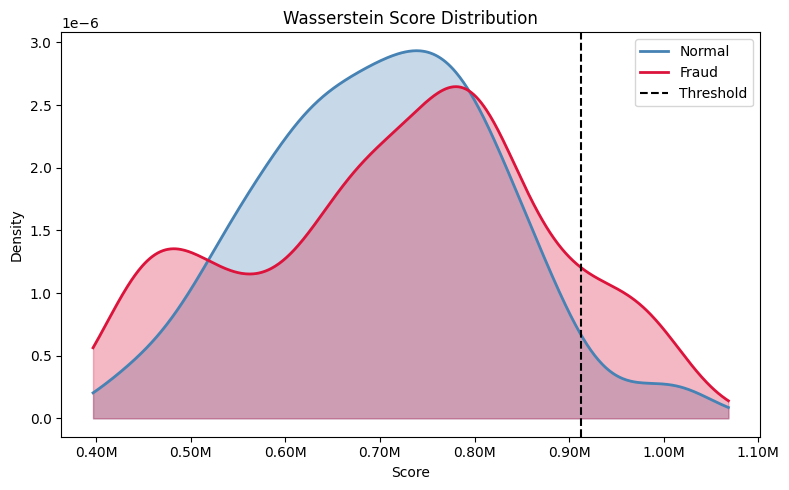

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))

normal_scores = scores[scores['Class'] == 0]['w_score'].values
fraud_scores  = scores[scores['Class'] == 1]['w_score'].values
x_range = np.linspace(scores['w_score'].min(), scores['w_score'].max(), 500)
kde_normal = gaussian_kde(normal_scores, bw_method=0.3)
kde_fraud  = gaussian_kde(fraud_scores,  bw_method=0.3)

ax.plot(x_range, kde_normal(x_range), color='steelblue', lw=2, label='Normal')
ax.fill_between(x_range, kde_normal(x_range), alpha=0.3, color='steelblue')
ax.plot(x_range, kde_fraud(x_range),  color='crimson',   lw=2, label='Fraud')
ax.fill_between(x_range, kde_fraud(x_range),  alpha=0.3, color='crimson')
ax.axvline(best_threshold, color='black', linestyle='--', lw=1.5, label='Threshold')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.2f}M'))
ax.set_title('Wasserstein Score Distribution')
ax.set_xlabel('Score')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.savefig('plot1_score_distribution.pdf', bbox_inches='tight')
plt.show()

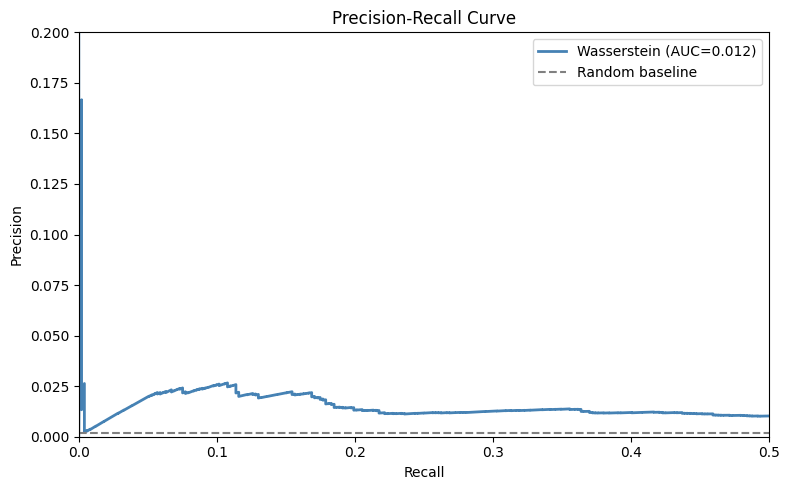

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(rec_curve, prec_curve, color='steelblue', lw=2,
        label=f'Wasserstein (AUC={pr_auc:.3f})')
ax.axhline(fraud_rate, color='gray', linestyle='--', label='Random baseline')
ax.set_xlim([0, 0.5])
ax.set_ylim([0, 0.2])
ax.set_title('Precision-Recall Curve')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend()
plt.tight_layout()
plt.savefig('plot3_pr_curve.pdf', bbox_inches='tight')
plt.show()

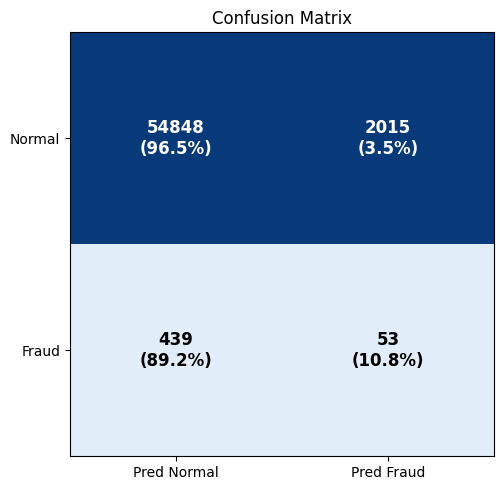

In [20]:
fig, ax = plt.subplots(figsize=(6, 5))

cm_norm = np.array([[cm[0,0]/cm[0].sum(), cm[0,1]/cm[0].sum()],
                     [cm[1,0]/cm[1].sum(), cm[1,1]/cm[1].sum()]])
cm_color = np.array([[cm_norm[0,0],       1 - cm_norm[0,1]],
                      [1 - cm_norm[1,0],   cm_norm[1,1]]])

ax.imshow(cm_color, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Pred Normal', 'Pred Fraud'])
ax.set_yticklabels(['Normal', 'Fraud'])
for i in range(2):
    for j in range(2):
        pct = cm_norm[i, j]
        ax.text(j, i, f'{cm[i,j]}\n({pct:.1%})',
                ha='center', va='center', fontsize=12, fontweight='bold',
                color='white' if cm_color[i,j] > 0.5 else 'black')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.savefig('plot4_confusion_matrix.pdf', bbox_inches='tight')
plt.show()

Summary

In [21]:
summary = pd.DataFrame({
    'Method'    : ['Naive (Amount threshold)', 'Wasserstein (ours)'],
    'Precision' : [precision_score(y_true, y_baseline, zero_division=0), precision],
    'Recall'    : [recall_score(y_true, y_baseline, zero_division=0),    recall],
    'F1-score'  : [f1_score(y_true, y_baseline, zero_division=0),        f1],
})

print(summary.to_string(index=False))

                  Method  Precision   Recall  F1-score
Naive (Amount threshold)   0.000000 0.000000  0.000000
      Wasserstein (ours)   0.025629 0.107724  0.041406
